In [ ]:
# AIRCRAFT TIRE CONTACT STRESS GENERATOR
# =============================================================================
# Reference: Airfield Pavement Response Caused by Heavy Aircraft Takeoff
# Hernandez & AL-Qadi, 2015 (TRB)
# =============================================================================
# This notebook computes tire contact stresses and exports results to Excel.
# Improvements: code structure, comments, folder organization, and efficiency.
# =============================================================================

# --- Imports ---
import os
import time
import numpy as np
import pandas as pd
import xlsxwriter
from openpyxl import load_workbook
import matplotlib.pyplot as plt
import seaborn as sns

# --- Folder Setup ---
INPUT_DIR = 'input_data'
OUTPUT_DIR = 'output'
if not os.path.exists(INPUT_DIR):
    os.makedirs(INPUT_DIR)
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- Utility Functions ---
def clear_terminal():
    os.system('cls' if os.name == 'nt' else 'clear')

clear_terminal()

# --- Timing ---
start = time.time()

# --- Input Parameters ---
P = 153463.65  # Load, [N]
l = 380.0      # Contact length [mm]
TiP = 1.379    # Tire inflation pressure [MPa]
Tire = 'P1'    # Load label, for file naming
RC = 'FR'      # Rolling condition, FR = Free-Rolling

# Contact geometry and stress factors
bi = [50.0, 35.0, 40., 90.0, 40.0, 35.0, 50.0]  # Contact width per rib [mm]
al = [0.24, 0.08, 0.08, 0.20, 0.08, 0.08, 0.24]  # Load carried by each rib
sigm_Tip = [1.8, 1.1, 1.1, 1.1, 1.1, 1.1, 1.8]  # Max vert stress factor per rib [MPa]
ssy_factor = 0.4  # SSY = ssy_factor*SSZ
nz = [2, 2, 2, 2, 2, 2, 2]  # Partitions per rib
l_elem = 38.0  # Element length [mm]

xn = l / l_elem    # Number of elements in contact length

# Arrays represeting the position of each node along the contact length
xloc = [(l_elem * i) - (l / 2.0) for i in range(int(xn) + 1)]
xnorm = [((l_elem * i) - (l / 2.0)) / (l / 2.0) for i in range(int(xn) + 1)]
xdist = [(l_elem * i) for i in range(int(xn) + 1)]

# Skewed parabola parameters for longitudinal stresses
lsx_pospk = 0.20
lsx_negpk = 0.85
sx_posmag = 0.20
sx_negmag = -0.15
skpb = 0.60
ssx_cut = xdist[int(round(skpb * len(xdist)))]

# Output Excel file name
xlname = os.path.join(OUTPUT_DIR, f'B787.xlsx')

# Percent diff threshold for equilibrium
pdiff = 5

# =============================================================================
# --- Main Calculations ---
# =============================================================================
# 1. Vertical contact stresses (SSZ)
SSZ = {}
for i, (a, b, s) in enumerate(zip(al, bi, sigm_Tip)):
    n = abs(1.0 / (2.0 * (((l * b * s * TiP) / (a * P)) - 1.0)))
    sz = [((a * P) / (l * b)) * (1.0 + (1.0 / (2.0 * n))) * (1 - (x ** 2.0) ** n) for x in xnorm]
    SSZ[f'Rib {i+1}'] = sz

# 2. Longitudinal contact stresses (SSX)
SSX = {}
x1 = [0, skpb * l]
x2 = [lsx_pospk * l, lsx_negpk * l]
x3 = [skpb * l, l]
y2 = [sx_posmag, sx_negmag]
a3 = [(x1[i] + x3[i] - (2.0 * x2[i])) / (x1[i] * x3[i] - (x2[i] ** 2.0)) for i in range(len(x1))]
a0 = [(-x1[i] * x3[i] * (a3[i] * x2[i] - 1) * y2[i]) / ((x1[i] - x2[i]) * (x3[i] - x2[i])) for i in range(len(x1))]
a1 = [((x1[i] + x3[i]) * (a3[i] * x2[i] - 1) * y2[i]) / ((x1[i] - x2[i]) * (x3[i] - x2[i])) for i in range(len(x1))]
a2 = [(y2[i] - a3[i] * x2[i] * y2[i]) / ((x1[i] - x2[i]) * (x3[i] - x2[i])) for i in range(len(x1))]
for i, (a, s) in enumerate(zip(al, sigm_Tip)):
    sx = []
    for j, x in enumerate(xdist):
        k = 0 if 0 <= x <= ssx_cut else 1
        sx.append(TiP * s * ((a2[k] * (x ** 2.0) + a1[k] * x + a0[k]) / (1.0 - (a3[k] * x))))
    SSX[f'Rib {i+1}'] = sx

# 3. Transverse contact stresses (SSY)
SSY = {f'Rib {i+1}': [ssy_factor * v for v in SSZ[f'Rib {i+1}']] for i in range(len(al))}

# 4. Average contact stresses for Abaqus input
axdist = [(xdist[i] + xdist[i + 1]) / 2.0 for i in range(int(xn))]

asz, asx, asy = {}, {}, {}
dfasz, dfasx, dfasy = {}, {}, {}
Eq_Pz = []
for i in range(len(al)):
    rib = f'Rib {i+1}'
    asz[rib] = [(SSZ[rib][j] + SSZ[rib][j + 1]) / 2.0 for j in range(int(xn))]
    asx[rib] = [(SSX[rib][j] + SSX[rib][j + 1]) / 2.0 for j in range(int(xn))]
    asy[rib] = [(SSY[rib][j] + SSY[rib][j + 1]) / 2.0 for j in range(int(xn))]
    sum_sz = []
    for j in range(nz[i]):
        # DataFrames for each stress type
        dfasz['coordX SSZ'] = axdist
        dfasz[f'{rib}_{j+1}'] = asz[rib]
        dfasx['coordX SSX'] = axdist
        dfasx[f'{rib}_{j+1}'] = asx[rib]
        dfasy['coordX SSY'] = axdist
        # Partition logic for transverse stresses
        if nz[i] == 4:
            if j == 0:
                dfasy[f'{rib}_{j+1}'] = asy[rib]
            elif j in [1, 2]:
                dfasy[f'{rib}_{j+1}'] = [0.00001] * len(asy[rib])
            elif j == 3:
                dfasy[f'{rib}_{j+1}'] = [-1.0 * v for v in asy[rib]]
        elif nz[i] == 3:
            if j == 0:
                dfasy[f'{rib}_{j+1}'] = asy[rib]
            elif j == 1:
                dfasy[f'{rib}_{j+1}'] = [0.00001] * len(asy[rib])
            elif j == 2:
                dfasy[f'{rib}_{j+1}'] = [-1.0 * v for v in asy[rib]]
        elif nz[i] == 2:
            if j == 0:
                dfasy[f'{rib}_{j+1}'] = asy[rib]
            elif j == 1:
                dfasy[f'{rib}_{j+1}'] = [-1.0 * v for v in asy[rib]]
        sum_sz.append(sum(np.array(dfasz[f'{rib}_{j+1}'])))
    Eq_Pz.append(sum(sum_sz) * l_elem * (bi[i] / nz[i]))

Calc_Pz = sum(Eq_Pz)
Diff = 100.0 * ((P - Calc_Pz) / P)
print(f'Calc = {Calc_Pz:.2f} kN, Applied = {P:.2f} kN')
print(f'Diff = {Diff:.2f} %')
if Diff > pdiff:
    print(f'Percent difference in calculated and applied load is greater than {pdiff}%!')
else:
    print(f'Equilibrium check passed! Difference is less than {pdiff}%!')

# --- Output to Excel ---
dfasz = pd.DataFrame(dfasz).set_index('coordX SSZ').T
dfasx = pd.DataFrame(dfasx).set_index('coordX SSX').T
dfasy = pd.DataFrame(dfasy).set_index('coordX SSY').T

sheetn = f'{Tire} P{round(P/1000)}kN S{TiP}MPa_{RC}'

# Save to Excel in output folder
with pd.ExcelWriter(xlname, engine='xlsxwriter') as writer:
    workbook = writer.book
    cell_format = workbook.add_format({'bold': True, 'italic': True})
    # Write SSV
    dfasz.to_excel(writer, sheet_name=sheetn, startrow=0)
    worksheet = writer.sheets[sheetn]
    worksheet.write(0, 0, 'SSV [MPa]', cell_format)
    # Write SSX
    start_row = (max(nz) * len(al)) + 2
    dfasx.to_excel(writer, sheet_name=sheetn, startrow=start_row)
    worksheet = writer.sheets[sheetn]
    worksheet.write(start_row, 0, 'SSX [MPa]', cell_format)
    # Write SSY
    start_row = 2 * start_row
    dfasy.to_excel(writer, sheet_name=sheetn, startrow=start_row)
    worksheet = writer.sheets[sheetn]
    worksheet.write(start_row, 0, 'SSY [MPa]', cell_format)

# --- Timing ---
end = time.time()
elapsed = end - start
print(f'Elapsed Time: {elapsed:.2f} seconds.')

Calc = 151847.04 kN, Applied = 153463.65 kN
Diff = 1.05 %
Equilibrium check passed! Difference is less than 5%!
Elapsed Time: 0.09 seconds.


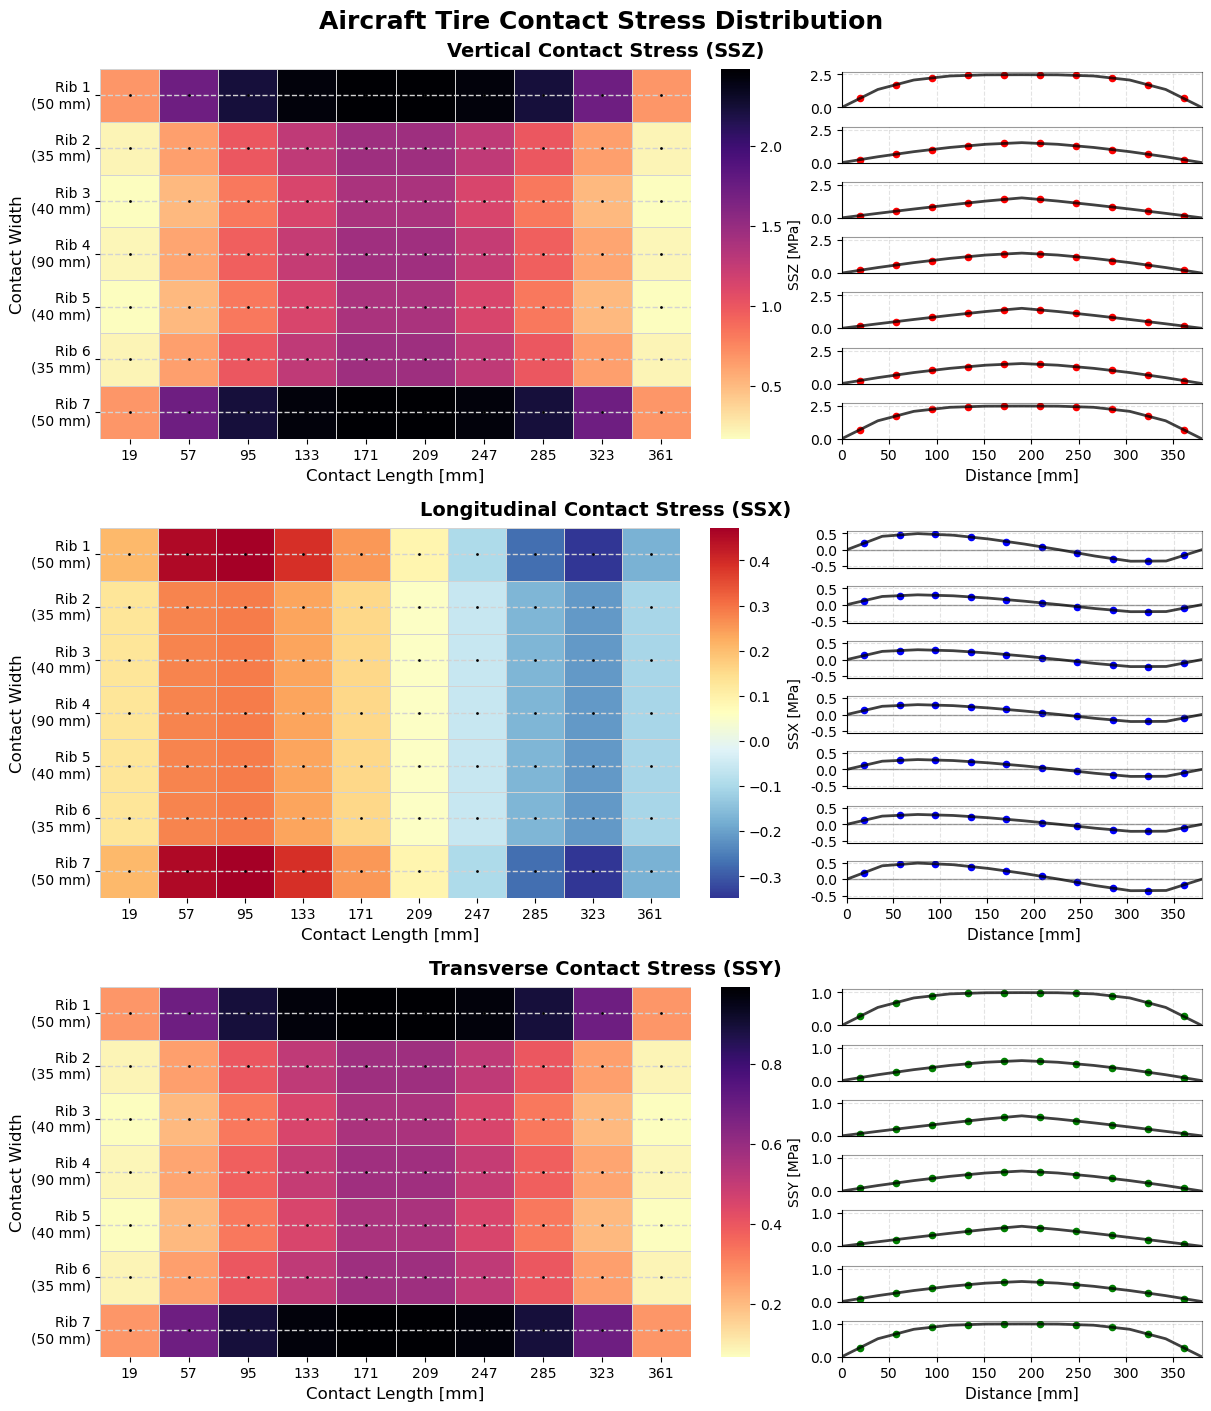

In [37]:
# --- Visualization: Heatmaps + rib-wise comparison plots (aligned) ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ssz_matrix = np.array([asz[f'Rib {i+1}'] for i in range(len(al))])
ssx_matrix = np.array([asx[f'Rib {i+1}'] for i in range(len(al))])
ssy_matrix = np.array([asy[f'Rib {i+1}'] for i in range(len(al))])

x_labels = [f'{x:.0f}' for x in axdist] 
y_labels = [f'Rib {i+1}\n({bi[i]:.0f} mm)' for i in range(len(bi))]
num_ribs = len(al)

stress_blocks = [
    dict(name="Vertical Contact Stress (SSZ)", mat=ssz_matrix, cmap="magma_r",
         cbar_label="SSZ [MPa]", theory=SSZ, x_scatter=axdist, x_theory=xdist, linecolor="#000000",
         ymode="positive"),
    dict(name="Longitudinal Contact Stress (SSX)", mat=ssx_matrix, cmap="RdYlBu_r",
         cbar_label="SSX [MPa]", theory=SSX, x_scatter=axdist, x_theory=xdist, linecolor="#000000",
         ymode="symmetric"),
    dict(name="Transverse Contact Stress (SSY)", mat=ssy_matrix, cmap="magma_r",
         cbar_label="SSY [MPa]", theory=SSY, x_scatter=axdist, x_theory=xdist, linecolor="#000000",
         ymode="positive"),
]

fig = plt.figure(figsize=(12, 14), dpi=100, layout="constrained")
subfigs = fig.subfigures(nrows=3, ncols=1)  # perfect row-wise alignment


colors = ["red", "blue", "green"]
for idx, block in enumerate(stress_blocks):
    subfig = subfigs[idx]
    subfig.suptitle(block["name"], fontsize=14, fontweight="bold")

    # Two main panels: (heatmap + cbar) | (rib stack)
    gs = subfig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.00, 0.50], wspace=0.20)

    # ---- Left panel: heatmap + dedicated colorbar axis (prevents layout drift) ----
    gs_left = gs[0, 0].subgridspec(1, 2, width_ratios=[20, 1], wspace=0.05)
    ax_hm  = subfig.add_subplot(gs_left[0, 0])
    ax_cbar = subfig.add_subplot(gs_left[0, 1])

    # Center SSX colormap at 0 for better interpretation
    heatmap_kwargs = dict(linewidths=0.5, linecolor="lightgrey", square=False, annot=False)
    if "seismic" in block["cmap"]:
        sns.heatmap(block["mat"], ax=ax_hm, cmap=block["cmap"], center=0.0,
                    cbar=True, cbar_ax=ax_cbar, cbar_kws={"label": block["cbar_label"]},
                    xticklabels=x_labels, yticklabels=y_labels, **heatmap_kwargs)
    else:
        sns.heatmap(block["mat"], ax=ax_hm, cmap=block["cmap"],
                    cbar=True, cbar_ax=ax_cbar, cbar_kws={"label": block["cbar_label"]},
                    xticklabels=x_labels, yticklabels=y_labels, **heatmap_kwargs)

    ax_hm.set_xlabel("Contact Length [mm]", fontsize=12)
    ax_hm.set_ylabel("Contact Width", fontsize=12)
    ax_hm.tick_params(axis="x", rotation=0)
    ax_hm.tick_params(axis="y", rotation=0)

    # Partition lines
    y_pos = 0
    for i, partitions in enumerate(nz):
        for p in range(1, partitions):
            ax_hm.axhline(y=y_pos + p*(1/partitions), color="lightgrey", linestyle="--", linewidth=1)
        y_pos += 1

    # Black points at cell centers
    num_x = block["mat"].shape[1]
    for i in range(num_ribs):
        for j in range(num_x):
            ax_hm.plot(j + 0.5, i + 0.5, marker="o", color="black", markersize=2, markeredgewidth=0)

    ##############################################################
    # ---- Right panel: rib stack (aligned to heatmap height) ----
    gs_right = gs[0, 1].subgridspec(num_ribs, 1, hspace=0.0)

    rib_axes = []
    for rib in range(num_ribs):
        ax_rib = subfig.add_subplot(gs_right[rib, 0], sharex=rib_axes[0] if rib_axes else None)
        rib_axes.append(ax_rib)

    # Consistent y-limits across ribs in this block (makes comparison clean)
    data_min = float(np.min(block["mat"]))
    data_max = float(np.max(block["mat"]))
    if block["ymode"] == "symmetric":
        y_abs = max(abs(data_min), abs(data_max))
        ylims = (-y_abs * 1.20, y_abs * 1.20)
    else:
        ylims = (0.0, data_max * 1.10)

    for rib, ax_rib in enumerate(rib_axes):
        # scatter = averaged (midpoints), theory = node-based curve
        ax_rib.plot(block["x_theory"], block["theory"][f"Rib {rib+1}"],
                    color=block["linecolor"], linestyle="-", alpha=0.75, linewidth=2.0)
        ax_rib.scatter(block["x_scatter"], block["mat"][rib], s=20, color=colors[idx])
        ax_rib.set_xlim(0.0, l)
        ax_rib.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))  ###
        ax_rib.set_ylim(*ylims)

        # Cleaner styling
        ax_rib.grid(True, linestyle="--", alpha=0.35)
        ax_rib.spines["top"].set_alpha(0.4)
        ax_rib.spines["right"].set_alpha(0.4)

        # Only bottom rib shows x tick labels; BUT xlabel always shown for each block (your request)
        if rib != num_ribs - 1:
            ax_rib.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        else:
            ax_rib.tick_params(axis="x", which="both", bottom=True, labelbottom=True)
            ax_rib.set_xlabel("Distance [mm]", fontsize=11)

        # Remove y-axis label clutter; keep ticks (optional)
        ax_rib.set_ylabel("")

        # Add a subtle zero line for SSX (helps interpret sign)
        if block["ymode"] == "symmetric":
            ax_rib.axhline(0.0, linewidth=1.0, alpha=0.35, color="black")

    # Single legend per block (top rib axis)
    #rib_axes[0].legend(["Theory", "Data"], loc="upper left", frameon=False, fontsize=9)

fig.suptitle("Aircraft Tire Contact Stress Distribution ", fontsize=18, fontweight="bold")
plt.show()
